# 3. Atraminių vektorių regresija (SVR–RBF) — pagrindinis metodas

**Failai:** `winequality/svr_model.py` (`rbf_kernel`, `predict_from_dual`, `formula_predict`)  
**Mokymas:** `winequality/tune.py` → `tune_svr` (hiperparametrai tik mokymo bloke)

Pasirinktas kaip pagrindinis, nes ε-nejautri nuostolio funkcija atitinka subjektyvų balą,
uždavinys iškilas (atkartojamas sprendinys), o Gauso branduolys modeliuoja netiesinius sąryšius.


## Formulės (naudojimo kelias — įgyvendinta kode)

Gauso branduolys:

\[
K(\mathbf{z}_i,\mathbf{z}) = \exp\bigl(-\gamma \|\mathbf{z}_i - \mathbf{z}\|^2\bigr)
\]

Dualinė prognozė (egzamino „formulė ↔ kodas“):

\[
f(\mathbf{z}) = \sum_{i \in \mathrm{SV}} (\alpha_i - \alpha_i^*)\, K(\mathbf{z}_i,\mathbf{z}) + b
\]

`sklearn.svm.SVR.dual_coef_` saugo būtent \((\alpha - \alpha^*)\), `support_vectors_` — \(\mathbf{z}_i\),
`intercept_` — \(b\). Funkcija `predict_from_dual` šią sumą skaičiuoja tiesiogiai.

Mokymas (vieną kartą, LIBSVM/SMO) minimizuoja

\[
\min_{\mathbf{w},b,\xi,\xi^*} \tfrac12\|\mathbf{w}\|^2 + C\sum_i(\xi_i+\xi_i^*)
\]

su ε-nejautriomis nelygybėmis: paklaidos, mažesnės už \(\varepsilon\), **nebaudžiamos**.


In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
root = here if (here / "winequality").exists() else here.parent
sys.path.insert(0, str(root))
sys.path.insert(0, str(root / "notebooks"))

from nb_pagalba import paruošti, metrikos_lentele, artefaktas
from winequality.config import FEATURE_NAMES, SPLIT_SEED

KIND = "red"  # pakeiskite į "white", jei norite balto vyno
duom = paruošti(KIND)
X_tr, y_tr, X_te, y_te = duom["X_tr"], duom["y_tr"], duom["X_te"], duom["y_te"]
print(f"{KIND}: mokymo n={duom['n_train']}, testo n={duom['n_test']}, sėkla={SPLIT_SEED}")
print("Požymiai:", FEATURE_NAMES)


red: mokymo n=1279, testo n=320, sėkla=0
Požymiai: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## Artefaktas (egzamino HPO) arba greitas demonstracinis mokymas


In [2]:
import joblib
from winequality.svr_model import formula_predict, svr_pipeline

kelias = artefaktas("svr", KIND)
if kelias.exists():
    bundle = joblib.load(kelias)
    vamzdis = bundle["pipeline"]
    print("Įkeltas artefaktas:", kelias.name)
    print(vamzdis.named_steps["svr"].get_params())
else:
    print("Artefakto nėra — mokomas demonstracinis SVR (be pilnos tinklelio paieškos).")
    vamzdis = svr_pipeline(C=2.0, epsilon=0.05, gamma=0.07)
    vamzdis.fit(X_tr, y_tr)

f_formule = formula_predict(vamzdis, X_te)
f_sklearn = vamzdis.predict(X_te)
print("max |formulė − sklearn| =", float(np.max(np.abs(f_formule - f_sklearn))))
print("Atraminių vektorių skaičius:", vamzdis.named_steps["svr"].support_vectors_.shape[0])


Įkeltas artefaktas: svr_red.joblib
{'C': np.float64(2.0958451823534987), 'cache_size': 256, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.05, 'gamma': np.float64(0.06897791679590747), 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}
max |formulė − sklearn| = 8.526512829121202e-14
Atraminių vektorių skaičius: 1125


## Testo metrikos


,modelis,MAE,MAE (apvalinta),Acc_0.5,Acc_1.0,κ_w,makro-F1
0,SVR-RBF,0.4734,0.4125,0.6094,0.9,0.5811,0.4698


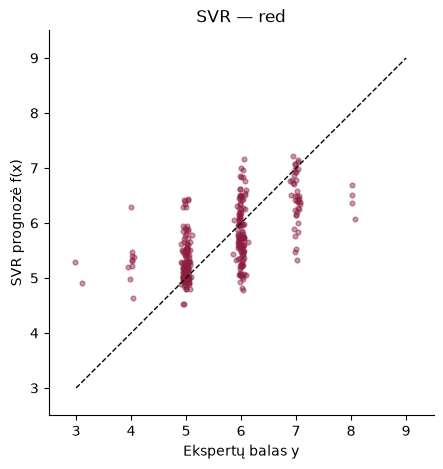

In [3]:
lentele = metrikos_lentele(y_te, f_formule, "SVR-RBF")
display(lentele.round(4))

fig, ax = plt.subplots(figsize=(5.0, 5.0))
ax.scatter(y_te + np.random.default_rng(0).normal(0, 0.04, size=len(y_te)), f_formule,
           s=12, alpha=0.45, c="#8b1e3f")
ax.plot([3, 9], [3, 9], "k--", lw=1)
ax.set_xlabel("Ekspertų balas y")
ax.set_ylabel("SVR prognozė f(x)")
ax.set_title(f"SVR — {KIND}")
ax.set_xlim(2.5, 9.5); ax.set_ylim(2.5, 9.5)
ax.set_aspect("equal")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


## Ką stebėti

- `max |formulė − sklearn|` turi būti ~\(10^{-13}\) — tai įrodymas, kad naudojama dualinė formulė, o ne „juodoji dėžė“.
- Raudonam vynui H1 (MAE ≤ 0,95 × tiesinės) šiame skaidyme **neįveikta** (~3,5 % geriau, reikia 5 %).
- Baltam vynui H1 **įveikta** (~6,9 %).
- Kraštiniai balai 3 ir 8–9 traukiami į vidurkį — subjektyvaus žymėjimo ir disbalanso padarinys.
